## 90 - Sunum figurleri (acil)

**Bu notebook izoledir.** Zincirin geri kalani (NB01-NB06) bunu okumaz,
import etmez, ciktisina bagimli degil. Sadece NB01'in yazdigi
`samples_clean.parquet` / `trials_clean.parquet` dosyalarini OKUR ve
`data/processed/sunum/` altina PNG yazar. Bu notebook ve
`src/presentation.py` silinirse baska hicbir sey etkilenmez.

### Soru

Gorsel gurultunun hangi seviyesi pendulum kontrolunu iyilestiriyor ve bu
etki kisiler arasinda tutarli mi?

### Noise seviyeleri (veriden, uydurma degil)

Her katilimcinin `metadata.json` dosyasindaki `config.noiseLevels` alani.
Etiketler grafiklerde hem kod adi hem sigma ile yazilir.

| id | sigma |
|---|---|
| no_noise | 0.00 |
| N1 | 0.02 |
| N2 | 0.05 |
| N3 | 0.08 |
| N4 | 0.25 |

Noise tipi: tam ekran uniform pixel noise, mid-grey +- sigma, 4 px element,
her display frame'de yenileniyor.

### Metrikler

Analiz birimi **katilimci x kosul** = 10 measurement trial'in ortalamasi.

| Metrik | Formul | Yon |
|---|---|---|
| Mean absolute angle | `mean(abs(theta))` | dusuk iyi |
| Successful stabilization | `abs(theta) <= 30 deg` olan sure, s/trial | yuksek iyi |
| Fall count | `fall_event` toplami / trial | dusuk iyi |
| Cart RMS | `sqrt(mean(x^2))` | **yon belirsiz** |

Cart RMS **kisisel optimal hesabina girmez**: dusuk cart salinimi hem "iyi
kontrol" hem "hic mudahale etmedi" anlamina gelebilir. Sadece incelemek
icin cizilir. Fall count bu notebook'ta toplam sayilir (aci vs ray
ayrimi yapilmaz).

### Reset frameleri

Sample maskesi `analysis_include` (NB01 §6):
`phase == "active" & practice == 0 & qc_pass & window_focused == 1`.
Reset frameleri tamamen disarida. Asagida her measurement trial'in tam
1200 active sample (20.0 s) icerdigi dogrulanir -- payda sabit, yani cok
dusen bir katilimci reset sayesinde yapay olarak iyi gorunmuyor.

In [1]:
%pip install -q pyyaml pandas numpy pyarrow matplotlib scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

ANALYSIS_ROOT = Path.cwd()
if not (ANALYSIS_ROOT / "config.yaml").exists():
    ANALYSIS_ROOT = ANALYSIS_ROOT.parent
sys.path.insert(0, str(ANALYSIS_ROOT))

from src import presentation as P

with open(ANALYSIS_ROOT / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)

INTERIM_DIR = ANALYSIS_ROOT / config["paths"]["interim_dir"]
FIG_DIR = ANALYSIS_ROOT / config["presentation"]["figure_dir"]
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

df_samples, df_trials = P.load_interim(INTERIM_DIR)
LABELS = P.condition_labels(df_samples)

print("samples :", df_samples.shape)
print("trials  :", df_trials.shape)
print("katilimci:", df_samples["participant_id"].nunique(),
      sorted(df_samples["participant_id"].unique()))
print("figur klasoru:", FIG_DIR)

samples : (846060, 25)
trials  : (636, 29)
katilimci: 12 ['P001', 'P002', 'P003', 'P004', 'P005', 'P006', 'P007', 'P008', 'P009', 'P010', 'P011', 'P012']
figur klasoru: C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\processed\sunum


### 1. On kontroller

Grafiklere gecmeden once uc sey dogrulanir. Bunlar gecmezse asagidaki
metrikler yanlis olur.

In [3]:
# --- 1a. reset frameleri disarida mi, payda sabit mi ---
active = df_samples[df_samples["analysis_include"]]
per_trial = active.groupby(["participant_id", "trial_id"]).size()
print("measurement trial sayisi :", len(per_trial))
print("trial basina active sample:", per_trial.min(), "-", per_trial.max())
print("hepsi 1200 mu             :", bool((per_trial == 1200).all()))
print("=> payda sabit 20.0 s\n")

# --- 1b. fall_event yalnizca active frameler'de mi ---
meas = df_samples[df_samples["practice"] == 0]
print("fall_event phase dagilimi:")
print(meas.groupby("phase")["fall_event"].sum().to_string())

# --- 1c. sample toplami Unity'nin fall_count'uyla uyusuyor mu ---
from_samples = (active.groupby(["participant_id", "trial_id"])["fall_event"]
                .sum().rename("from_samples"))
from_summary = (df_trials[df_trials["practice"] == 0]
                .set_index(["participant_id", "trial_id"])["fall_count"]
                .rename("from_summary"))
chk = pd.concat([from_samples, from_summary], axis=1)
print("\nfall sayimi trial bazinda ayni mi:",
      bool((chk["from_samples"] == chk["from_summary"]).all()),
      "| toplam dusus:", int(chk["from_samples"].sum()))

# --- 1d. QC ---
print("\nQC'den dusen trial:", int((~df_trials["qc_pass"]).sum()))

measurement trial sayisi : 600
trial basina active sample: 1200 - 1200
hepsi 1200 mu             : True
=> payda sabit 20.0 s



fall_event phase dagilimi:
phase
active    1156
reset        0

fall sayimi trial bazinda ayni mi: True | toplam dusus: 1156

QC'den dusen trial: 0


### 2. Metrikler

Once trial duzeyi, sonra katilimci x kosul duzeyinde ozetlenir.

In [4]:
trial_df = P.trial_metrics(df_samples, config)
pc = P.participant_condition_metrics(trial_df)
pcd = P.baseline_delta(pc, config)

print("trial duzeyi :", trial_df.shape)
print("katilimci x kosul:", pc.shape,
      "| hucre basina trial:", sorted(pc["n_trials"].unique()))
trial_df.head()

trial duzeyi : (600, 13)
katilimci x kosul: (60, 13) | hucre basina trial: [np.int64(10)]


,participant_id,noise_level_id,noise_sigma,trial_id,trial_order,round_index,mae_angle_deg,falls_per_trial,cart_rms_m,n_samples,active_s,success_time_s,success_pct
0,P001,N1,0.02,T004,1,1,12.890435,2.0,1.213125,1200,20.0004,17.167010,85.835050
1,P001,N1,0.02,T009,6,2,13.286132,2.0,1.197708,1200,20.0004,18.800376,94.001880
2,P001,N1,0.02,T014,11,3,13.557235,1.0,1.120940,1200,20.0004,17.433682,87.168410
3,P001,N1,0.02,T023,20,4,17.176002,2.0,1.505796,1200,20.0004,15.683647,78.418235
4,P001,N1,0.02,T028,25,5,13.760002,2.0,2.027430,1200,20.0004,18.283699,91.418495


In [5]:
# Grup ozeti: kosul basina ortalama +- SEM
metrics = list(P.METRIC_INFO)
grp = (pc.groupby("noise_level_id", observed=True)[metrics]
         .agg(["mean", "sem"]).round(3))
grp

mae_angle_deg        success_time_s        falls_per_trial        cart_rms_m       
                        mean    sem           mean    sem            mean    sem       mean    sem
noise_level_id                                                                                    
no_noise              11.247  0.978         18.366  0.398           1.825  0.606      1.090  0.075
N1                    11.198  0.966         18.491  0.354           1.708  0.599      1.126  0.069
N2                    12.282  0.937         18.047  0.383           1.975  0.670      1.017  0.085
N3                    12.508  0.895         18.082  0.361           1.917  0.619      1.144  0.078
N4                    12.658  0.849         18.088  0.355           2.208  0.697      1.043  0.075

In [6]:
# Baseline'a gore kisi-ici ortalama fark (isaretler metrigin kendi biriminde)
delta_cols = [m + "_delta" for m in metrics]
(pcd.groupby("noise_level_id", observed=True)[delta_cols]
    .agg(["mean", "sem"]).round(3))

mae_angle_deg_delta        success_time_s_delta        falls_per_trial_delta        cart_rms_m_delta       
                              mean    sem                 mean    sem                  mean    sem             mean    sem
noise_level_id                                                                                                            
no_noise                     0.000  0.000                0.000  0.000                 0.000  0.000            0.000  0.000
N1                          -0.049  0.469                0.125  0.178                -0.117  0.177            0.036  0.041
N2                           1.034  0.254               -0.319  0.111                 0.150  0.190           -0.073  0.039
N3                           1.261  0.311               -0.284  0.135                 0.092  0.146            0.054  0.060
N4                           1.410  0.424               -0.278  0.180                 0.383  0.178           -0.047  0.025

### 2b. Bagimsiz dogrulama: ayni sayilar ham CSV'den cikiyor mu

Yukaridaki kontroller zincirin *icinden* bakiyor. Bu bolum disaridan
bakiyor: dort metrigi Unity'nin yazdigi `<pid>_<sid>_timeseries.csv`
dosyalarindan sifirdan hesaplar. Parquet okumaz, `loader.py` / `qc.py`
kullanmaz, `analysis_include` kolonuna bakmaz -- maskeyi elle kurar:

    practice == 0  &  phase == "active"  &  window_focused == 1

Boylece ayni hatanin zincirin iki ucunda birden tekrarlanma ihtimali
dusuyor. Iki sayi birebir tutuyorsa (fark < 1e-9, yani float yuvarlama)
sunumdaki rakamlar dogrulanmis olur.

Reset konusu burada iki kez bagimsiz kontrol ediliyor: maskede
`phase == "active"` var, ayrica `is_resetting` kolonundan da reset
satiri sizmadigi dogrulaniyor. `active_s` sutunu her katilimcida
20.0-20.0 cikmali -- payda sabit demek, yani cok dusen biri reset
sayesinde yapay olarak iyi gorunmuyor.

In [7]:
RAW_DIR = ANALYSIS_ROOT / config["presentation"]["raw_dir_for_check"]
raw_summary, raw_trials, problems = P.raw_verification(RAW_DIR, config)

print("HAM CSV'den (parquet ve src/ zinciri kullanilmadan):")
print(raw_summary.round(3).to_string())
print()
print("reset sizintisi:", problems if problems else "yok")
print("trial basina active sure araligi:",
      raw_summary["active_s_min"].min(), "-", raw_summary["active_s_max"].max())

HAM CSV'den (parquet ve src/ zinciri kullanilmadan):
                n_trial  active_s_min  active_s_max  mae_angle_deg  falls_per_trial  success_time_s  cart_rms_m
participant_id                                                                                                 
P001                 50          20.0          20.0         14.441             1.62          17.553       1.450
P002                 50          20.0          20.0         11.537             0.38          18.804       1.337
P003                 50          20.0          20.0         12.853             1.68          17.850       1.266
P004                 50          20.0          20.0         15.852             3.32          16.784       1.118
P005                 50          20.0          20.0          8.098             0.16          19.572       0.866
P006                 50          20.0          20.0          9.261             0.28          19.272       0.956
P007                 50          20.0          20.0

In [8]:
cmp_df, joined = P.compare_raw_vs_pipeline(raw_trials, trial_df)
print("Ham CSV ile parquet zinciri ayni trial'da ayni sonucu veriyor mu:")
print(cmp_df.to_string(index=False))
assert cmp_df["birebir_ayni"].all(), "HAM VERI ILE ZINCIR UYUSMUYOR"
print()
print("OK -- dort metrik de birebir tutuyor.")

Ham CSV ile parquet zinciri ayni trial'da ayni sonucu veriyor mu:
                             metric  eslesen_trial  en_buyuk_fark  birebir_ayni
          Mean absolute angle (deg)            600   0.000000e+00          True
Successful stabilization (s / 20 s)            600   1.065814e-14          True
             Fall count (per trial)            600   0.000000e+00          True
              Cart RMS position (m)            600   4.440892e-16          True

OK -- dort metrik de birebir tutuyor.


### 3. Figur 1-4: metrik x noise seviyesi

Her figurde:

- **Sol panel** grup gorunumu: 12 ince gri cizgi = katilimcilar, kalin
  lacivert = grup ortalamasi +- SEM (katilimcilar uzerinden). Y ekseni
  ortak, yani katilimcilar arasi seviye farki burada gorunur.
- **Sag paneller** katilimci basina ayri grafik. Hata cubugu = o
  hucredeki 10 trial'in SEM'i, kirmizi yildiz = o katilimcinin en iyi
  kosulu.

**Sag panellerin y ekseni ortak DEGIL, her panel kendi araliginda.**
Katilimcilar arasi seviye farki cok buyuk (or. fall count'ta P005 ~0,
P007 ~5-8 dusus/trial); ortak eksende cogu panel duz cizgiye donuyor ve
kisi-ici oruntu okunmuyor. Asil soru "bu kiside noise ne yapiyor" oldugu
icin eksen serbest. Seviye bilgisi kaybolmasin diye panel basliginda o
katilimcinin 5 kosul ortalamasi yazili. Paneller arasi yukseklik
karsilastirilamaz.

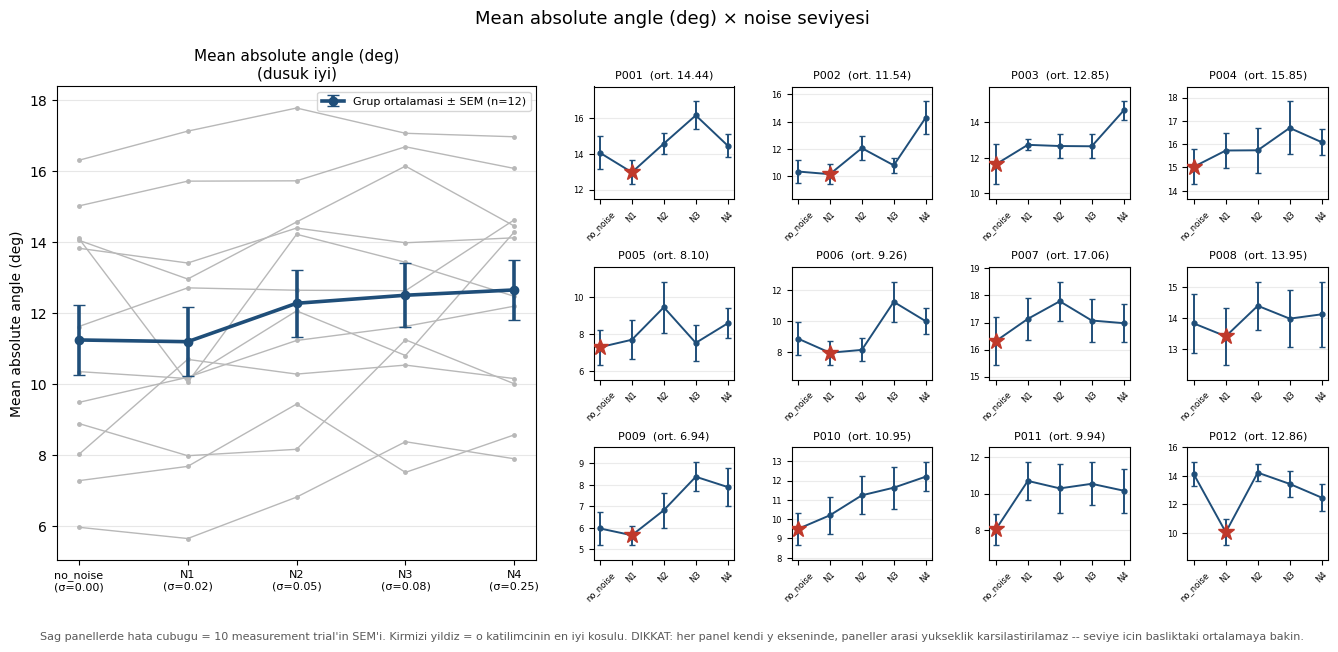

C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\processed\sunum\fig_mae_angle_deg.png


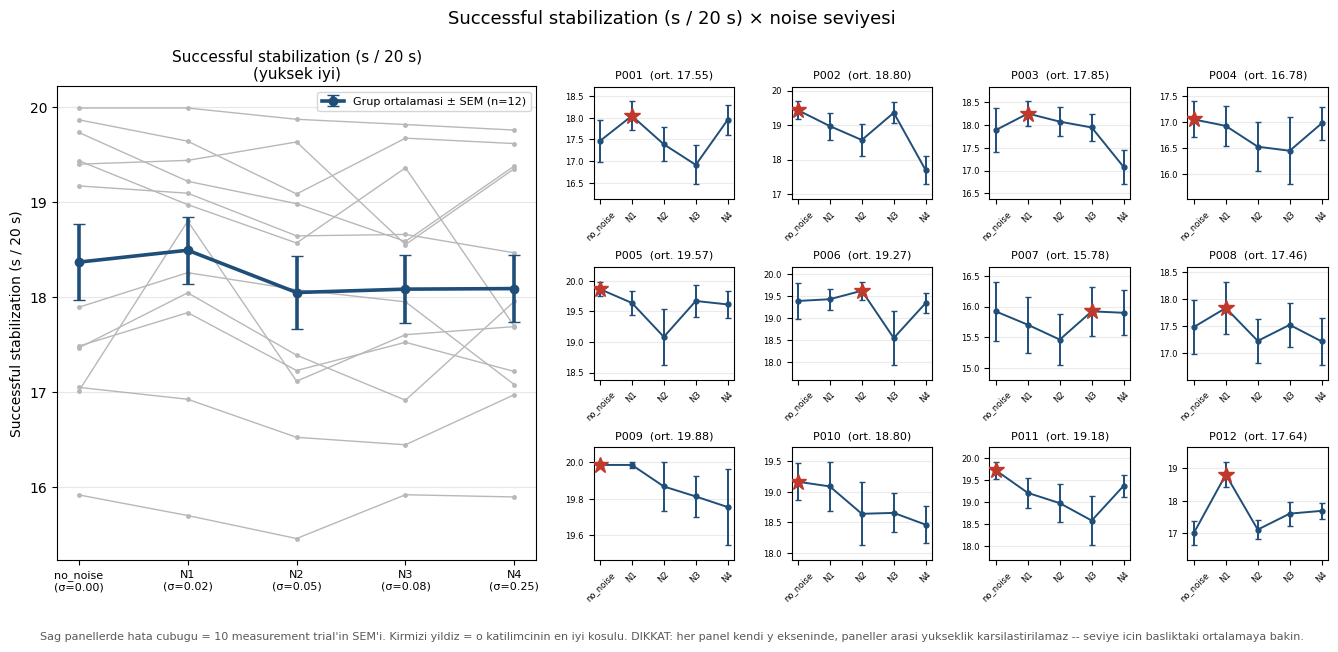

C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\processed\sunum\fig_success_time_s.png


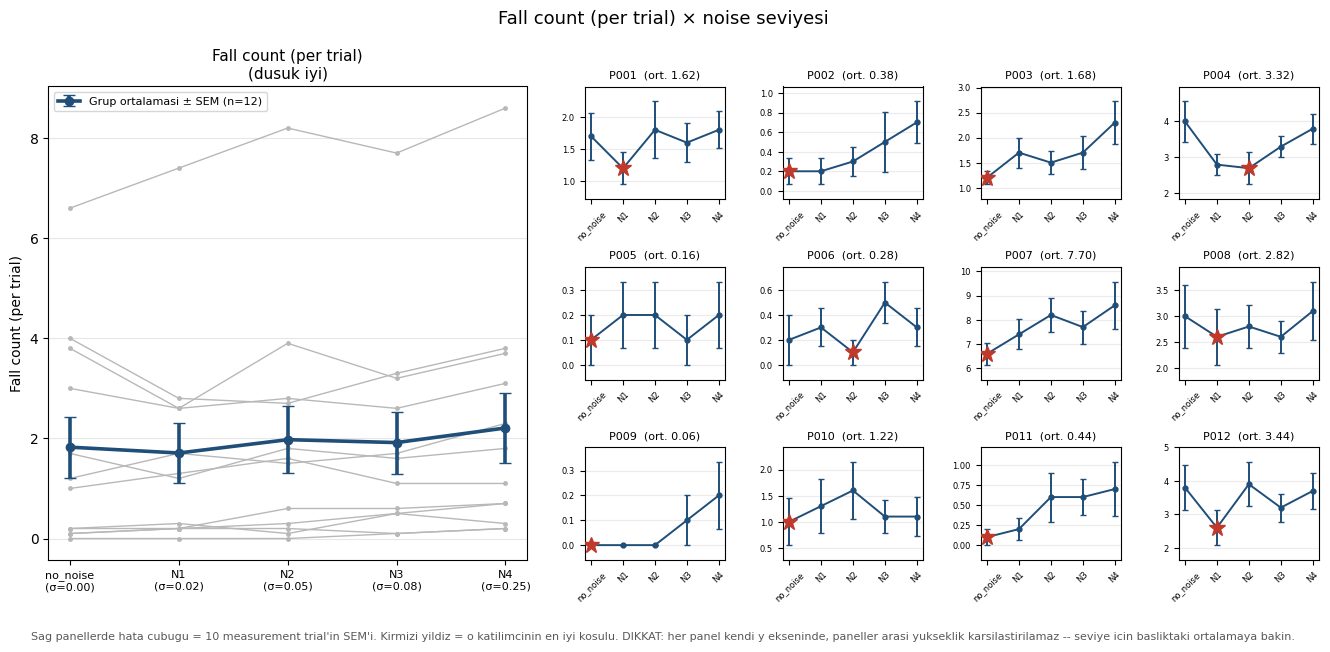

C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\processed\sunum\fig_falls_per_trial.png


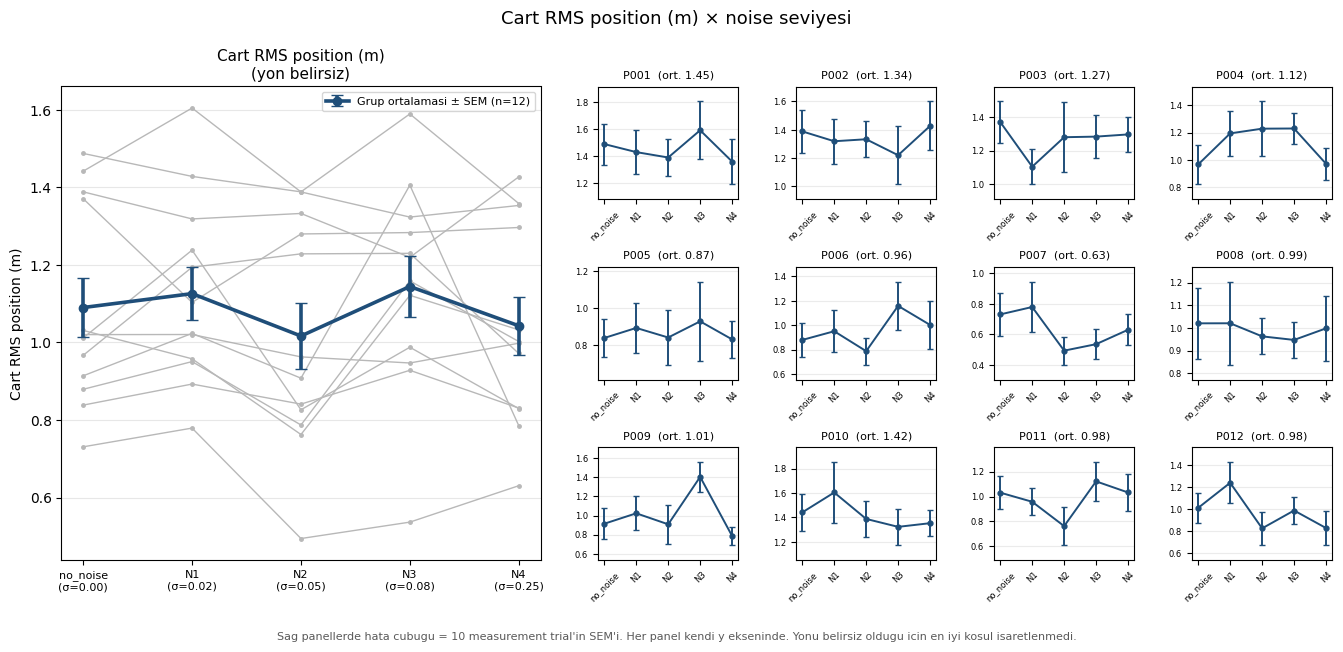

C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\processed\sunum\fig_cart_rms_m.png


In [9]:
paths = {}
for m in P.METRIC_INFO:
    fig, path = P.fig_metric(pc, m, config, ANALYSIS_ROOT, LABELS)
    paths[m] = path
    plt.show()
    print(path)

### 4. Figur 5: heatmap - katilimci x kosul, baseline'a gore degisim

Olcek metrige gore secilir (`P.HEATMAP_SCALE`):

| Metrik | Olcek | Neden |
|---|---|---|
| Mean absolute angle | yuzde | baseline hep > 0 |
| Successful stabilization | saniye farki | 20 s'lik trial'da saniye yuzdeden somut |
| **Fall count** | **mutlak fark** | **P009'un no_noise fall sayisi tam 0 -- yuzde tanimsiz olurdu** |
| Cart RMS | yuzde | baseline hep > 0 |

Hucre yazisi metrigin kendi isaretinde. Renk **yorumlanmis**: yesil =
iyilesme, kirmizi = kotulesme; yonu ters olan metriklerde (MAE, fall)
renk icin isaret cevrilir, yazi cevrilmez. Cart RMS'in yonu belirsiz
oldugu icin rengi yorum olarak okunmamali.

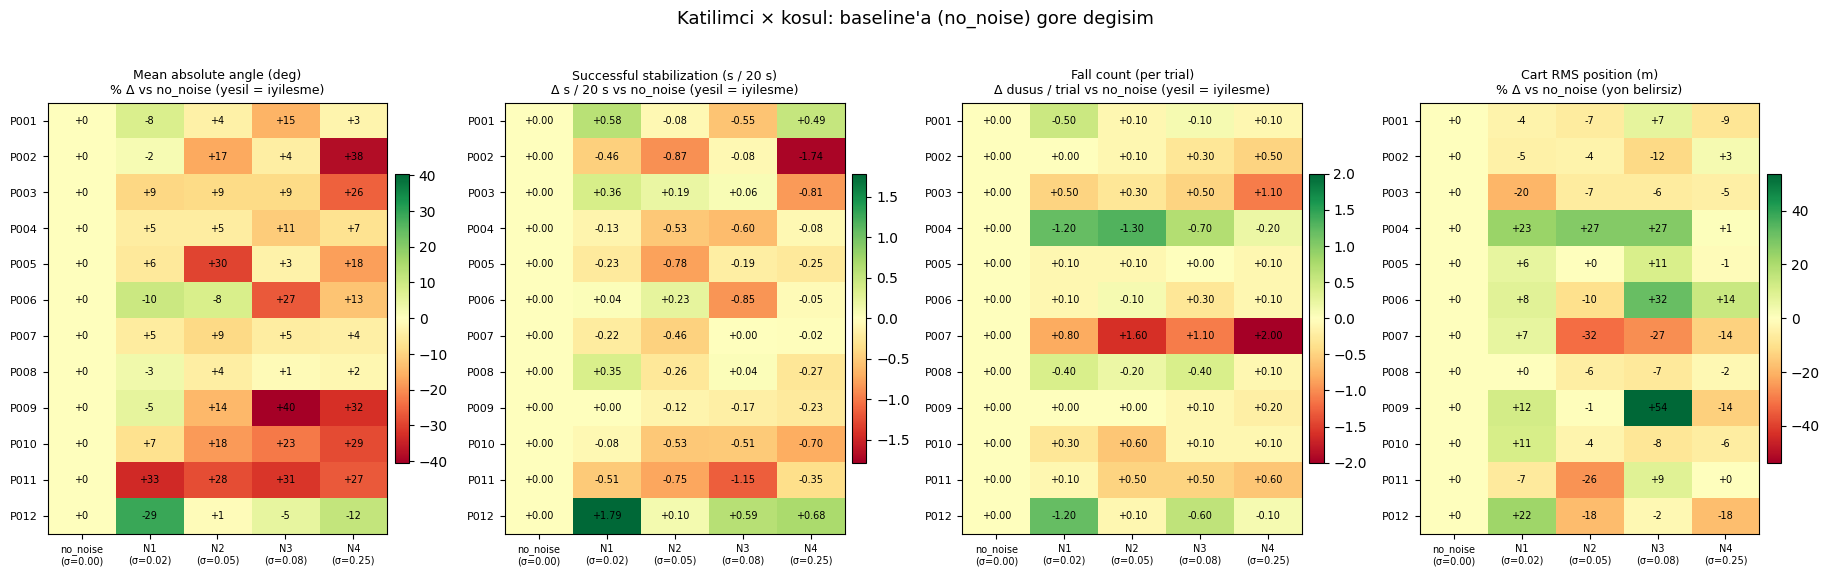

C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\processed\sunum\fig_heatmap_delta.png


In [10]:
fig, path = P.fig_heatmap(pcd, config, ANALYSIS_ROOT, LABELS)
plt.show()
print(path)

### 5. Figur 6: kisisel optimal noise seviyesi

Her katilimci icin her metrik kendi icinde siralanir (1 = en iyi).
**Composite** = yonu net olan uc metrigin (MAE, successful stabilization,
fall count) rank toplami; en dusuk toplam optimal kabul edilir. Minimum
toplam birden fazla seviyede paylasiliyorsa "Belirsiz" yazilir -- 10
tekrarlik pilotta sahte kesinlik verilmez.

Cart RMS yonu belirsiz oldugu icin composite'e girmez.

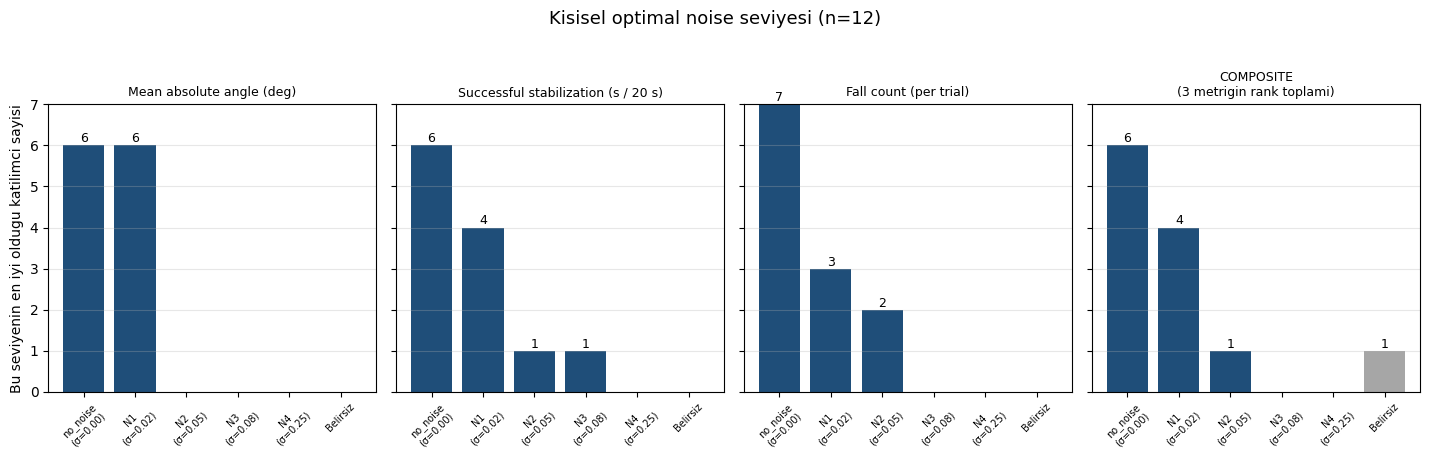

C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\processed\sunum\fig_personal_best.png


In [11]:
best = P.personal_best(pc, config)
fig, path = P.fig_personal_best(best, config, ANALYSIS_ROOT, LABELS)
plt.show()
print(path)

In [12]:
# Kisisel optimal tablosu: her metrigin en iyisi + composite + baseline farki
base = config["presentation"]["baseline_condition"]
tbl = best[["participant_id", "best_mae_angle_deg", "best_success_time_s",
            "best_falls_per_trial", "optimal", "tied_with", "margin"]].copy()

opt_rows = []
for _, r in best.iterrows():
    cond = r["optimal"]
    if cond == "Belirsiz":
        opt_rows.append({"participant_id": r["participant_id"],
                         "mae_pct": np.nan, "success_delta_s": np.nan,
                         "falls_delta": np.nan})
        continue
    row = pcd[(pcd["participant_id"] == r["participant_id"]) &
              (pcd["noise_level_id"] == cond)].iloc[0]
    opt_rows.append({"participant_id": r["participant_id"],
                     "mae_pct": row["mae_angle_deg_pct"],
                     "success_delta_s": row["success_time_s_delta"],
                     "falls_delta": row["falls_per_trial_delta"]})

tbl = tbl.merge(pd.DataFrame(opt_rows), on="participant_id")
tbl = tbl.rename(columns={
    "best_mae_angle_deg": "best_MAE",
    "best_success_time_s": "best_success",
    "best_falls_per_trial": "best_falls",
    "optimal": "OPTIMAL", "tied_with": "beraberlik",
    "mae_pct": "MAE % (vs " + base + ")",
    "success_delta_s": "success delta (s)",
    "falls_delta": "falls delta"})
tbl.round(2)

,participant_id,best_MAE,best_success,best_falls,OPTIMAL,beraberlik,margin,MAE % (vs no_noise),success delta (s),falls delta
0,P001,N1,N1,N1,N1,,5.0,-7.77,0.58,-0.5
1,P002,N1,no_noise,no_noise,no_noise,,1.0,0.00,0.00,0.0
2,P003,no_noise,N1,no_noise,no_noise,,1.0,0.00,0.00,0.0
3,P004,no_noise,no_noise,N2,Belirsiz,"no_noise, N1",0.0,NaN,NaN,NaN
4,P005,no_noise,no_noise,no_noise,no_noise,,2.0,0.00,0.00,0.0
5,P006,N1,N2,N2,N2,,2.0,-8.18,0.23,-0.1
6,P007,no_noise,N3,no_noise,no_noise,,3.0,0.00,0.00,0.0
7,P008,N1,N1,N1,N1,,3.0,-3.01,0.35,-0.4
8,P009,N1,no_noise,no_noise,N1,,1.0,-5.31,0.00,0.0
9,P010,no_noise,no_noise,no_noise,no_noise,,5.0,0.00,0.00,0.0


### 6. Figur 7: ogrenme / trial sirasi kontrolu

Kosul sirasi butun katilimcilarda ozdes (randomizationSeed 12345'e
sabitlenmis, bkz. CLAUDE.md "Veride gorulen sorunlar" §1). Bu yuzden
"gec gelen kosul daha iyi gorunur mu" sorusu acikca kontrol edilmeli.

Sol uc panel: trial sirasina karsi performans, katilimci-ici merkezlenmis
(kisiler arasi seviye farki egilimi bogmasin diye). Siyah cizgi 10'lu blok
ortalamasi. Sag panel: her kosulun trial sirasindaki dagilimi -- kutular
ust uste biniyorsa kosullar ogrenme ekseninde dengelenmis demektir.

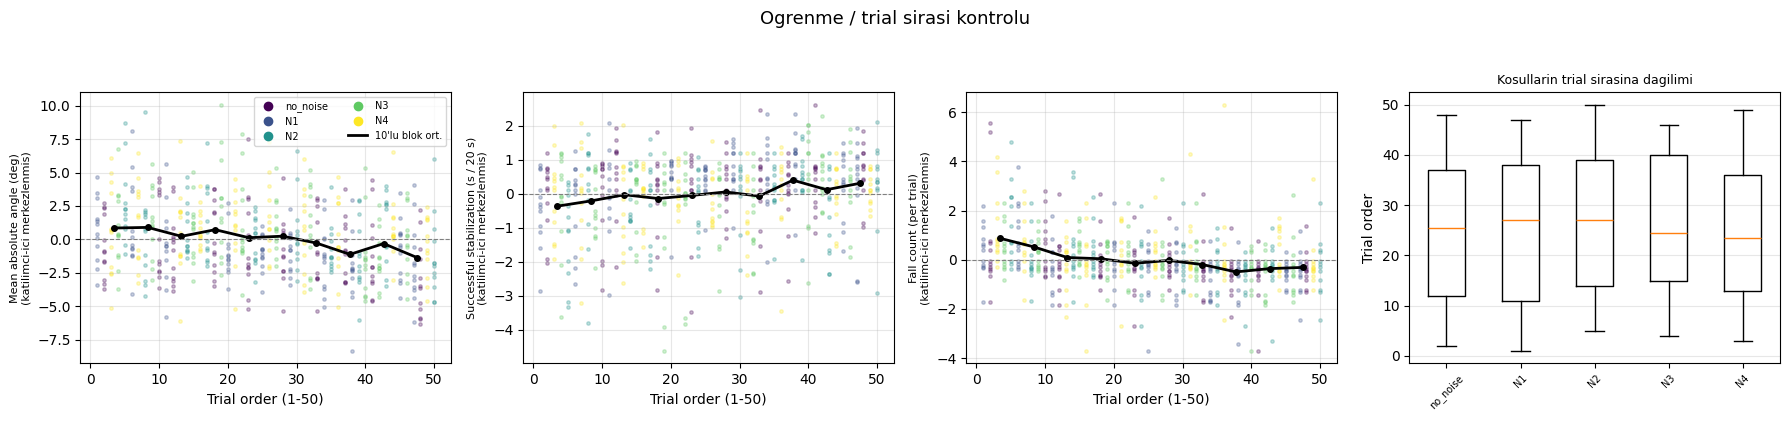

C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\processed\sunum\fig_trial_order.png

Kosul basina ortalama trial_order (1-50 araliginda):
                mean    std
noise_level_id             
N1              25.6  15.24
N2              26.5  14.63
N3              25.6  13.65
N4              24.6  14.70
no_noise        25.2  14.12


In [13]:
fig, path = P.fig_trial_order(trial_df, config, ANALYSIS_ROOT, LABELS)
plt.show()
print(path)

print("\nKosul basina ortalama trial_order (1-50 araliginda):")
print(trial_df.groupby("noise_level_id", observed=True)["trial_order"]
      .agg(["mean", "std"]).round(2).to_string())

### 6b. Basari esigi: "basarili dengeleme" tanimini degistirirsek ne olur

#### Neden bu bolum var

`success_time_s` su an "pole `|theta| <= 30` derece icindeyken gecen sure"
demek. Bu esik gevsek: active zamanin **%91'i** zaten basarili sayiliyor.
Metrik tavana yapisik oldugu icin bes kosul 18.0 ile 18.5 saniye arasina
sikisiyor -- fark var ama dar bir seride.

Esigi daraltinca ayni fark daha genis bir araliga yayiliyor. Bu bolum
esigi 5 dereceden 45 dereceye kadar tarayip her birinde sonucun ne
oldugunu gosteriyor.

#### Tablodaki sutunlar ne anlama geliyor

**tavan_pct** -- zamanin yuzde kaci "basarili" sayiliyor. %100'e
yaklastikca herkes basarili gorunur ve metrik ayirt etme gucunu
kaybeder. 45 derecede %97; 10 derecede %58, yani dagilimin ortasi.

**friedman_p** -- "bes kosul arasindaki fark gercek mi, yoksa sans mi"
sorusunun cevabi. Deger sunu soyluyor: *aslinda hic fark olmasaydi,
elimizdeki kadar farki tesadufen gorme ihtimali.* 0.02 ise %2 demek,
yani sansa baglamak zor. Genel kabul 0.05'in altini "sans degil"
saymak. Friedman testini sectik cunku ayni 12 kisi bes kosulun hepsini
yapti (kisileri kendileriyle karsilastiriyoruz) ve verinin can egrisine
uydugunu varsaymiyor.

**linear_p** -- ayni mantik, ama "noise arttikca duzenli bir bozulma var
mi" sorusuna odakli.

**dz** -- etki buyuklugu. p degeri "fark var mi" der, "fark ne kadar
buyuk" demez; cok kisiyle calisirsan minicik bir fark bile p < 0.05
cikabilir. dz farkin buyuklugunu kisiden kisiye oynakliga bolerek
olcuyor:

    dz = (N4 ile no_noise farkinin ortalamasi) / (bu farkin kisiler
         arasi standart sapmasi)

Kabaca 0.2 kucuk, 0.5 orta, 0.8 uzeri buyuk etki sayilir.

**ayni_yonde_kisi** -- en sezgisel sutun: 12 kisiden kacinda fark ayni
yonde cikmis.

#### Somut okuma

`|theta| <= 30` derecede N4 ile baseline arasinda ortalama 0.28 saniye
fark var ve kisiler -1.74 ile +0.68 arasinda sacilryor -- yani fark
kisiler arasi daginikligin icinde kayboluyor, dz = 0.45.
`|theta| <= 10` derecede fark 1.38 saniyeye cikiyor, sacilma benzer
kaliyor, dz = 1.30. Duz Turkcesiyle: **12 kisiden 11'inde en yuksek
noise'da kisi 10 derece icinde yaklasik 1.4 saniye daha az kalmis.**

#### UYARI

Esigi sonuca bakarak secmek p-hacking olur. Bu tablo esik SECMEK icin
degil, sonucun esik secimine duyarli OLMADIGINI gostermek icin. Ana
figurler `config.presentation.success_angle_deg` (su an 30 derece) ile
cizilir; asagidaki her esik icin ayri grafik seti de uretilir, boylece
istenirse baska bir esik sunulabilir.

In [14]:
sweep = P.threshold_sweep(df_samples, config)
cols = (["esik_deg"] + P.CONDITION_ORDER +
        ["tavan_pct", "friedman_p", "linear_p", "dz",
         "ayni_yonde_kisi", "ort_fark_s"])
sweep[cols].round(4)

,esik_deg,no_noise,N1,N2,N3,N4,tavan_pct,friedman_p,linear_p,dz,ayni_yonde_kisi,ort_fark_s
0,5,7.1585,7.0653,6.5786,6.2340,6.1003,33.1366,0.0050,0.0005,-1.3373,10,-1.0582
1,10,12.3986,12.2015,11.5816,11.0848,11.0158,58.2823,0.0004,0.0005,-1.3001,11,-1.3828
2,15,15.0343,15.0420,14.3906,14.0682,13.9501,72.4852,0.0005,0.0005,-1.0770,11,-1.0842
3,20,16.6413,16.6381,16.1021,16.0620,15.9052,81.3487,0.0103,0.0024,-0.8130,11,-0.7361
4,25,17.7270,17.7109,17.2647,17.2415,17.1909,87.1349,0.0146,0.0010,-0.6549,10,-0.5361
5,30,18.3662,18.4912,18.0469,18.0824,18.0881,91.0749,0.0212,0.0049,-0.4462,10,-0.2781
6,45,19.4871,19.5207,19.3544,19.3929,19.3779,97.1329,0.0180,0.0068,-0.5062,8,-0.1092


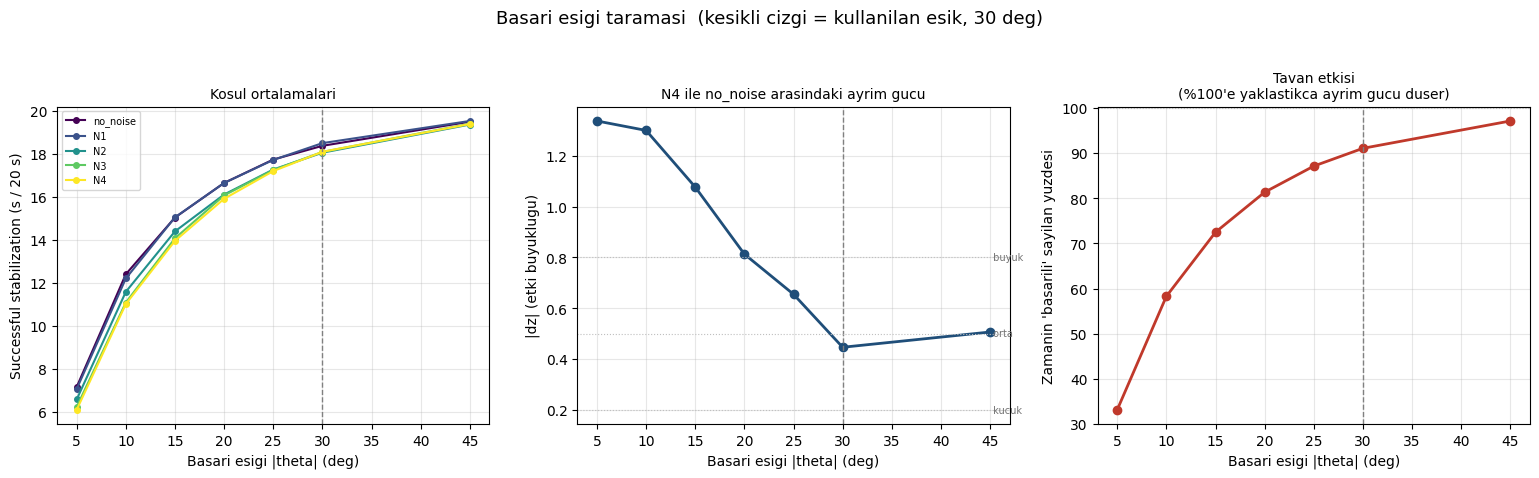

C:\Users\elifa\Documents\GitHub\NOROM_Inv_Pendulum\Data Analysis\data\processed\sunum\fig_threshold_sweep.png

Okuma: her esikte ayni yon, ayni anlamlilik. Sonuc esik secimine
dayanikli. Dar esikte ayrim gucu artiyor cunku tavan etkisi azaliyor.


In [15]:
fig, path = P.fig_threshold_sweep(sweep, config, ANALYSIS_ROOT)
plt.show()
print(path)

print()
print("Okuma: her esikte ayni yon, ayni anlamlilik. Sonuc esik secimine")
print("dayanikli. Dar esikte ayrim gucu artiyor cunku tavan etkisi azaliyor.")

#### Her esik icin ayri grafik seti

Asagida her basari esigi icin figur 2'nin (successful stabilization)
tam hali uretiliyor: solda grup gorunumu, sagda katilimci basina panel.
Duzen ana figurlerle ayni, tek fark baslikta ve dosya adinda esigin
yazili olmasi.

Dosyalar: `fig_success_thr05.png`, `fig_success_thr10.png`, ...
Sunumda hangisini kullanacagina bakip secebilirsin.

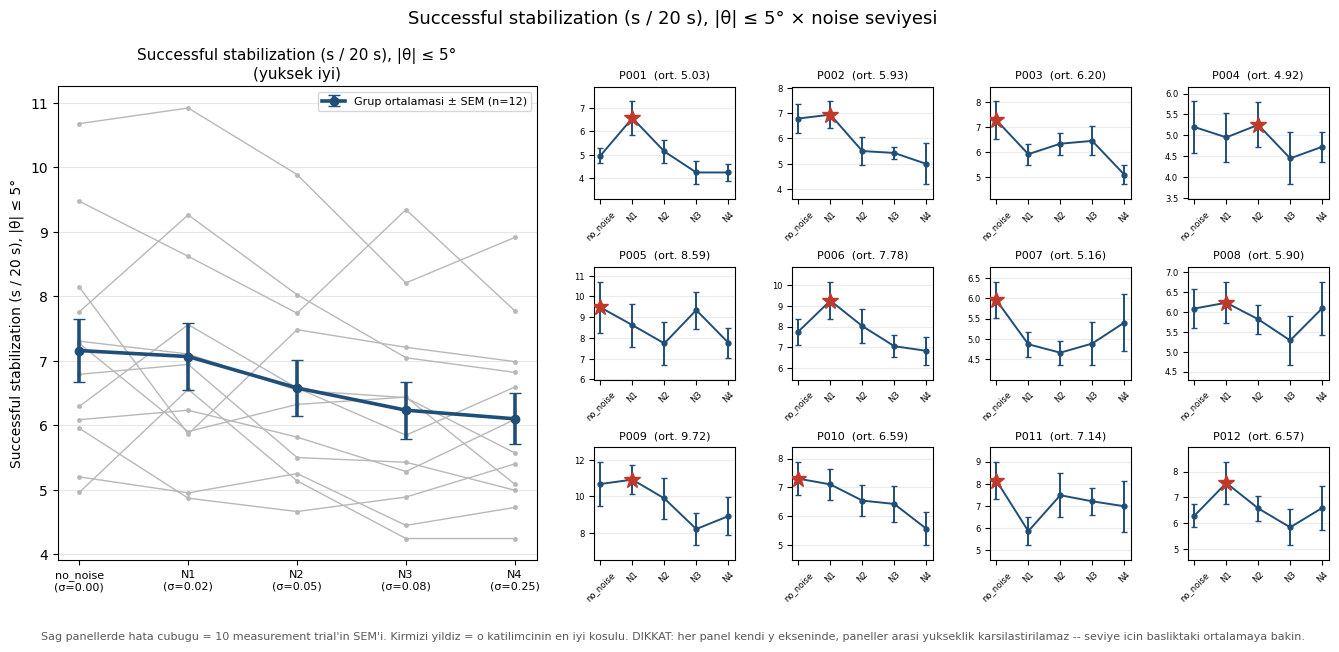

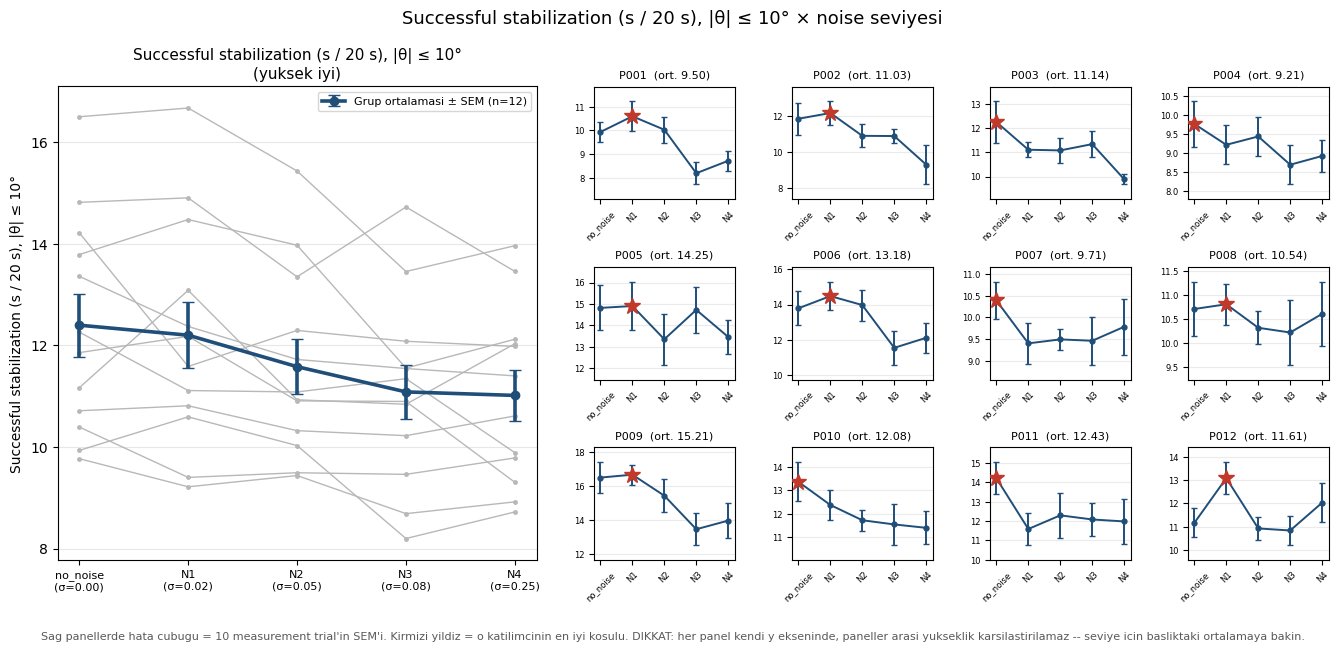

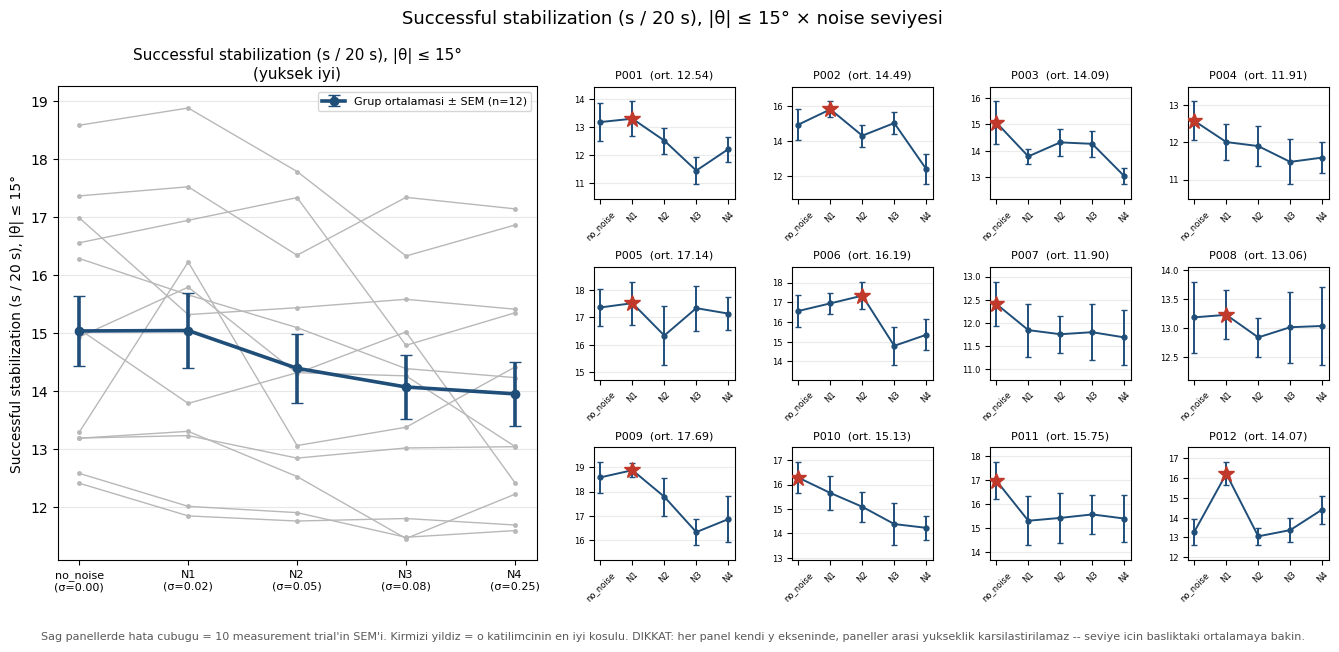

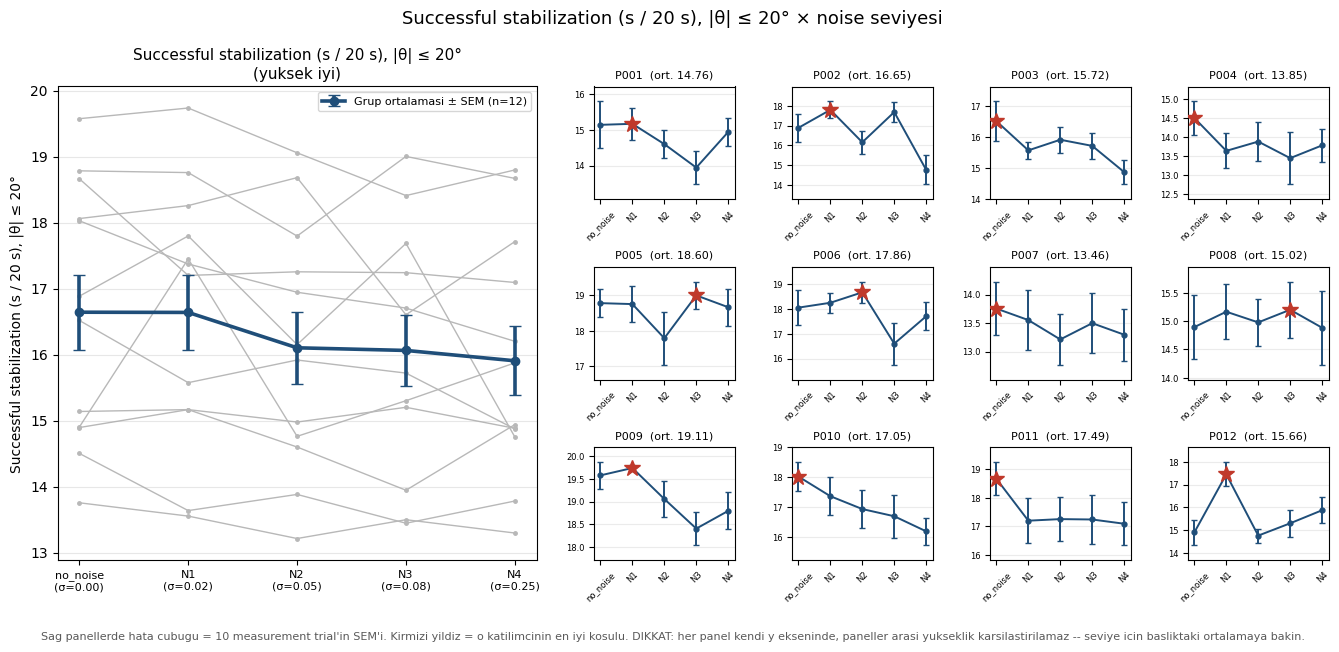

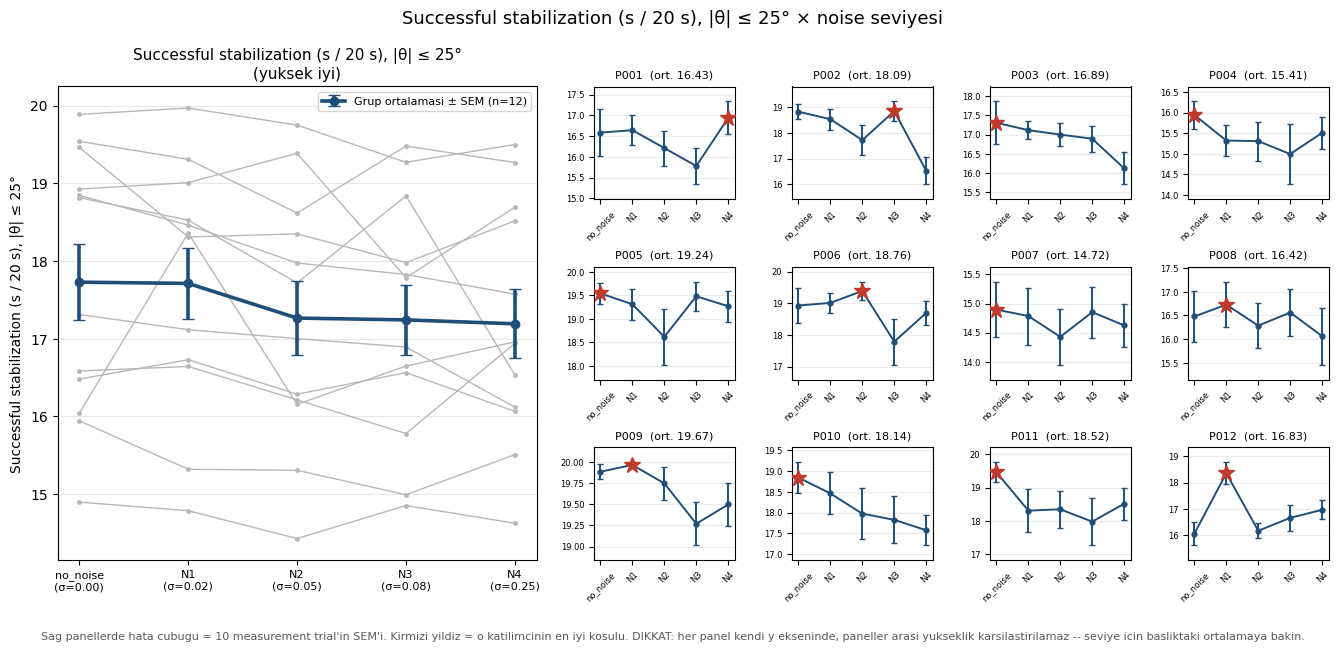

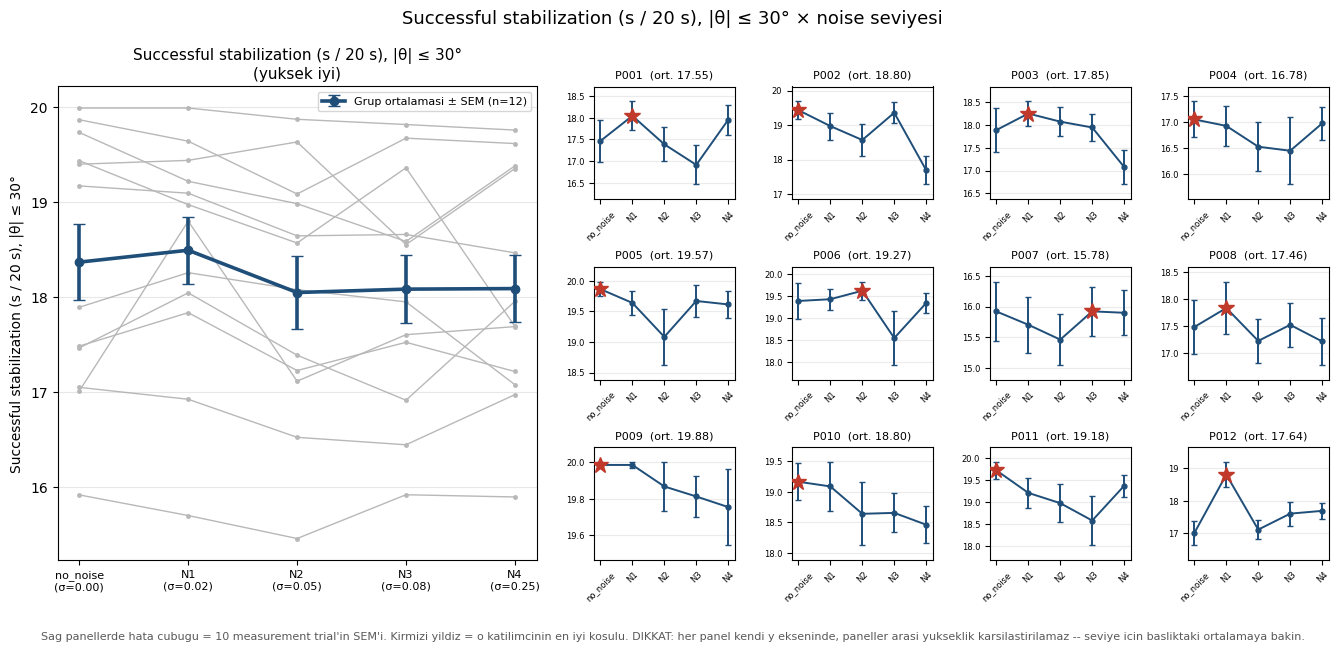

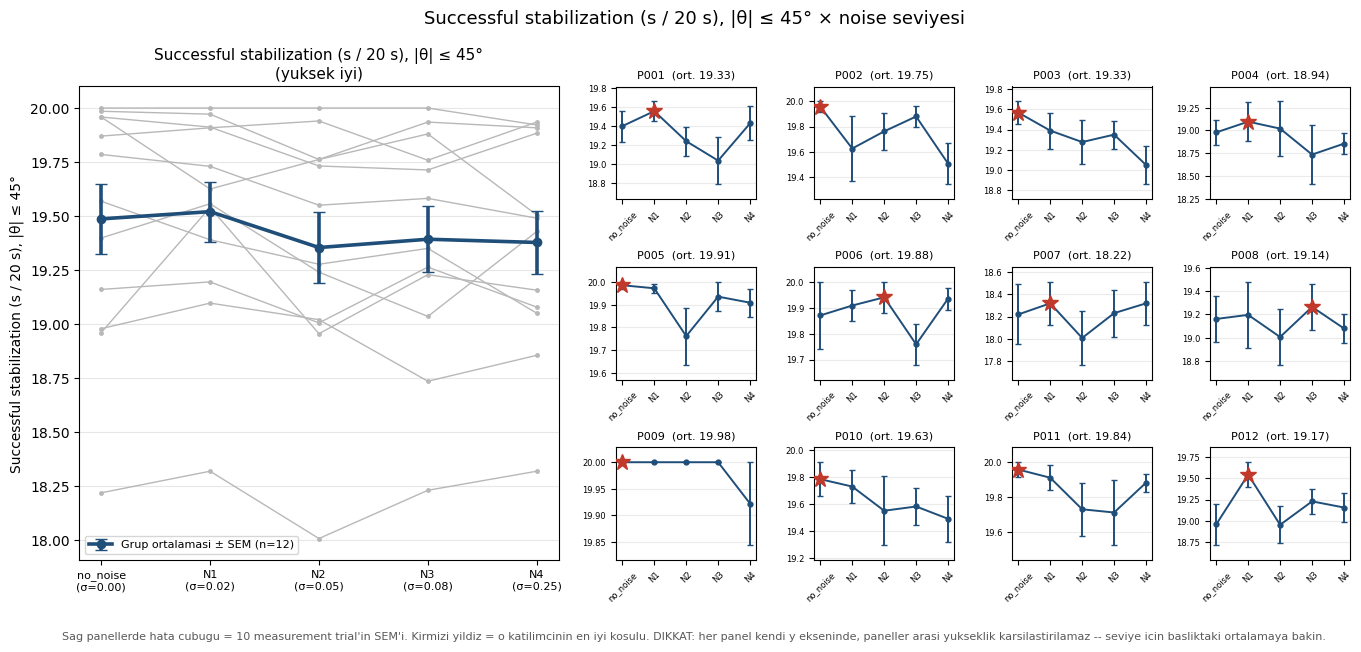

esik 5 deg -> fig_success_thr05.png
esik 10 deg -> fig_success_thr10.png
esik 15 deg -> fig_success_thr15.png
esik 20 deg -> fig_success_thr20.png
esik 25 deg -> fig_success_thr25.png
esik 30 deg -> fig_success_thr30.png
esik 45 deg -> fig_success_thr45.png


In [16]:
thr_figs = P.fig_success_all_thresholds(df_samples, config, ANALYSIS_ROOT,
                                        LABELS)
for thr, fig, path in thr_figs:
    plt.show()
    print("esik {:g} deg ->".format(thr), path.name)

### 7. Stats

Pilot, n=12, kisi-ici tasarim. Parametrik varsayim yapilmiyor.

- **Friedman**: 5 kosul arasinda fark var mi
- **Wilcoxon (Holm)**: her noise seviyesi baseline'a karsi
- **Lineer / kuadratik trend**: her katilimcinin 5 kosul ortalamasina
  ortogonal polinom kontrasti uygulanir, kontrast skorlari uzerinde tek
  orneklem Wilcoxon. **Kuadratik terim "U sekli var mi" sorusunun
  dogrudan testidir.**

Kontrastlar ordinal pozisyon uzerinden (sigma degerleri esit arali degil
ve sifir icerdigi icin log alinamiyor).

In [17]:
stats_df = P.stats_table(pc, config)
stats_df.round(4).T

,0,1,2,3
metric,Mean absolute angle (deg),Successful stabilization (s / 20 s),Fall count (per trial),Cart RMS position (m)
n,12,12,12,12
direction,-1,1,-1,0
friedman_chi2,17.8,11.5314,13.9107,7.1333
friedman_p,0.0014,0.0212,0.0076,0.129
linear_contrast,4.1304,-0.9649,0.975,-0.0757
linear_p,0.0005,0.0049,0.001,0.6772
quadratic_contrast,-0.4603,0.2413,0.4917,-0.0373
quadratic_p,0.6221,0.5693,0.3105,1.0
N1_vs_base_p,0.9097,0.8984,0.7988,0.4238


In [18]:
# Ozet okuma
for _, r in stats_df.iterrows():
    print(r["metric"])
    print("   Friedman  chi2={:.2f}  p={:.4f}".format(
        r["friedman_chi2"], r["friedman_p"]))
    print("   lineer    kontrast={:+.3f}  p={:.4f}".format(
        r["linear_contrast"], r["linear_p"]))
    print("   kuadratik kontrast={:+.3f}  p={:.4f}   <- U sekli testi".format(
        r["quadratic_contrast"], r["quadratic_p"]))
    for c in ["N1", "N2", "N3", "N4"]:
        print("   {:<9} vs baseline  p={:.4f}  (Holm {:.4f})".format(
            c, r[c + "_vs_base_p"], r[c + "_vs_base_p_holm"]))
    print()

Mean absolute angle (deg)
   Friedman  chi2=17.80  p=0.0014
   lineer    kontrast=+4.130  p=0.0005
   kuadratik kontrast=-0.460  p=0.6221   <- U sekli testi
   N1        vs baseline  p=0.9097  (Holm 0.9097)
   N2        vs baseline  p=0.0049  (Holm 0.0146)
   N3        vs baseline  p=0.0034  (Holm 0.0137)
   N4        vs baseline  p=0.0093  (Holm 0.0186)

Successful stabilization (s / 20 s)
   Friedman  chi2=11.53  p=0.0212
   lineer    kontrast=-0.965  p=0.0049
   kuadratik kontrast=+0.241  p=0.5693   <- U sekli testi
   N1        vs baseline  p=0.8984  (Holm 0.8984)
   N2        vs baseline  p=0.0269  (Holm 0.1074)
   N3        vs baseline  p=0.0640  (Holm 0.1919)
   N4        vs baseline  p=0.0923  (Holm 0.1919)

Fall count (per trial)
   Friedman  chi2=13.91  p=0.0076
   lineer    kontrast=+0.975  p=0.0010
   kuadratik kontrast=+0.492  p=0.3105   <- U sekli testi
   N1        vs baseline  p=0.7988  (Holm 1.0000)
   N2        vs baseline  p=0.2168  (Holm 0.6504)
   N3        vs base

### 8. Output

Figurler `data/processed/sunum/` altinda PNG. Tablolar ayni klasore CSV
olarak da yazilir ki slaytta gerekirse kullanilabilsin.

In [19]:
FIG_DIR.mkdir(parents=True, exist_ok=True)
pc.to_csv(FIG_DIR / "participant_condition_metrics.csv", index=False)
pcd.to_csv(FIG_DIR / "participant_condition_baseline_delta.csv", index=False)
best.to_csv(FIG_DIR / "personal_best.csv", index=False)
stats_df.to_csv(FIG_DIR / "stats.csv", index=False)
sweep.to_csv(FIG_DIR / "threshold_sweep.csv", index=False)
raw_summary.to_csv(FIG_DIR / "raw_verification.csv")
trial_df.to_csv(FIG_DIR / "trial_metrics.csv", index=False)

for f in sorted(FIG_DIR.iterdir()):
    print(f.name)

fig_cart_rms_m.png
fig_falls_per_trial.png
fig_heatmap_delta.png
fig_mae_angle_deg.png
fig_personal_best.png
fig_success_thr05.png
fig_success_thr10.png
fig_success_thr15.png
fig_success_thr20.png
fig_success_thr25.png
fig_success_thr30.png
fig_success_thr45.png
fig_success_time_s.png
fig_threshold_sweep.png
fig_trial_order.png
participant_condition_baseline_delta.csv
participant_condition_metrics.csv
personal_best.csv
raw_verification.csv
stats.csv
threshold_sweep.csv
trial_metrics.csv
